In [2]:
import geemap
import ee

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\ANDERSONALVESCOELHO\anaconda3\envs\geo\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


In [3]:
# Roda o comando no terminal : earthengine authenticate --auth_mode=notebook
ee.Authenticate()
ee.Initialize(project="spatial-yew-490017-r3")
print(ee.String("Hello from the Earth Engine servers!").getInfo())

Hello from the Earth Engine servers!


In [4]:
import ee
ee.Authenticate()
ee.Initialize(project="spatial-yew-490017-r3")
print(ee.Number(1).add(1).getInfo())  # deve retornar 2 sem erro

2


In [5]:
# Asset oficial do MapBiomas Brasil - Coleção 9 (LULC, 1985-2023)

collection9 = ee.Image(
    "projects/mapbiomas-public/assets/brazil/lulc/collection9/mapbiomas_collection90_integration_v1"
)

collection = collection9.bandNames().getInfo()
print("Total:", len(collection))
print("Primeiras bands:", collection[:5])
print("Últimas bands:", collection[-5:])

Total: 39
Primeiras bands: ['classification_1985', 'classification_1986', 'classification_1987', 'classification_1988', 'classification_1989']
Últimas bands: ['classification_2019', 'classification_2020', 'classification_2021', 'classification_2022', 'classification_2023']


In [6]:
year = 2020
classification_map = collection9.select(f"classification_{year}")
classification_map

In [7]:
MAPBIOMAS_COLLECTION9_LEGEND = {
    1: "#1f8d49",  # Floresta
    3: "#1f8d49",  # Formação Florestal
    4: "#7dc975",  # Formação Savânica
    5: "#04381d",  # Mangue
    6: "#007785",  # Floresta Alagável
    9: "#7a5900",  # Silvicultura
    10: "#d6bc74",  # Vegetação Herbácea e Arbustiva
    11: "#519799",  # Campo Alagado e Área Pantanosa
    12: "#d6bc74",  # Formação Campestre
    14: "#ffefc3",  # Agropecuária
    15: "#edde8e",  # Pastagem
    18: "#e974ed",  # Agricultura
    19: "#c27ba0",  # Lavoura Temporária
    20: "#db7093",  # Cana
    21: "#ffefc3",  # Mosaico de Usos
    22: "#d4271e",  # Área não Vegetada
    23: "#ffa07a",  # Praia, Duna e Areal
    24: "#d4271e",  # Área Urbanizada
    25: "#db4d4f",  # Outras Áreas não Vegetadas
    26: "#2532e4",  # Corpo D'água
    29: "#ffaa5f",  # Afloramento Rochoso
    30: "#9c0027",  # Mineração
    31: "#091077",  # Aquicultura
    32: "#fc8114",  # Apicum
    33: "#2532e4",  # Rio, Lago e Oceano
    35: "#9065d0",  # Dendê
    36: "#d082de",  # Lavoura Perene
    39: "#f5b3c8",  # Soja
    40: "#c71585",  # Arroz
    41: "#f54ca9",  # Outras Lavouras Temporárias
    46: "#d68fe2",  # Café
    47: "#9932cc",  # Citrus
    48: "#e6ccff",  # Outras Lavouras Perenes
    49: "#02d659",  # Restinga Arbórea
    50: "#ad5100",  # Restinga Herbácea
    62: "#ff69b4",  # Algodão (beta)
    75: "#c12100",  # Usina Fotovoltaica (beta)
}

CLASS_NAMES = {
    1: "Floresta",
    3: "Formação Florestal",
    4: "Formação Savânica",
    5: "Mangue",
    6: "Floresta Alagável",
    9: "Silvicultura",
    10: "Veg. Herbácea/Arbustiva",
    11: "Campo Alagado",
    12: "Formação Campestre",
    14: "Agropecuária",
    15: "Pastagem",
    18: "Agricultura",
    19: "Lavoura Temporária",
    20: "Cana",
    21: "Mosaico de Usos",
    22: "Área não Vegetada",
    23: "Praia/Duna/Areal",
    24: "Área Urbanizada",
    25: "Outras Áreas não Vegetadas",
    26: "Corpo D'água",
    29: "Afloramento Rochoso",
    30: "Mineração",
    31: "Aquicultura",
    32: "Apicum",
    33: "Rio/Lago/Oceano",
    35: "Dendê",
    36: "Lavoura Perene",
    39: "Soja",
    40: "Arroz",
    41: "Outras Lavouras Temporárias",
    46: "Café",
    47: "Citrus",
    48: "Outras Lavouras Perenes",
    49: "Restinga Arbórea",
    50: "Restinga Herbácea",
    62: "Algodão (beta)",
    75: "Usina Fotovoltaica (beta)",
}

In [8]:
roi = ee.Geometry.Point([-47.57191962529561 , -14.146454832272571]).buffer(100000)

clipped_map = classification_map.clip(roi)

class_values = list(MAPBIOMAS_COLLECTION9_LEGEND.keys())
class_palette = [color.lstrip("#") for color in MAPBIOMAS_COLLECTION9_LEGEND.values()]

remapped = classification_map.remap(class_values, list(range(len(class_values))))
vis_params_exact = {"min": 0, "max": len(class_values) - 1, "palette": class_palette}

landsat_collection = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(roi)
    .filterDate(f"{year}-01-01", f"{year}-12-31")
    .filter(ee.Filter.lt("CLOUD_COVER", 20))
)

landsat_image = landsat_collection.median().clip(roi)

sr_bands = ["SR_B4", "SR_B3", "SR_B2"]
landsat_vis = {"bands": sr_bands, "min": 7000, "max": 20000, "gamma": 1.2}


map_display = geemap.Map()
map_display.add_basemap("HYBRID")
map_display.centerObject(roi, 10)
map_display.addLayer(landsat_image, landsat_vis, f"Landsat 8 - {year}")
map_display.addLayer(remapped.clip(roi), vis_params_exact, f"Collection 9 - {year}")
map_display

Map(center=[-14.146352260157837, -47.57191669187571], controls=(WidgetControl(options=['position', 'transparen…

In [ ]:
def get_area_by_class(image, geometry, scale=30):
    pixel_area_ha = ee.Image.pixelArea().divide(10000)
    result = pixel_area_ha.addBands(image).reduceRegion(
        reducer=ee.Reducer.sum().group(groupField=1, groupName="class"),
        geometry=geometry,
        scale=scale,
        maxPixels=1e9,
    )
    groups = ee.List(result.get("groups")).getInfo()
    df = pd.DataFrame(groups).rename(columns={"sum": "area_ha", "class": "class_id"})
    df["class_id"] = df["class_id"].astype(int)
    df["class_name"] = df["class_id"].map(CLASS_NAMES)
    df["color"] = df["class_id"].map(MAPBIOMAS_COLLECTION9_LEGEND)
    return df.sort_values("area_ha", ascending=False)


: 

In [ ]:
# 1. Quantitativo por classe - barra
df_year = get_area_by_class(clipped_map, roi)

plt.figure(figsize=(10, 6))
plt.bar(df_year["class_name"], df_year["area_ha"], color=df_year["color"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Área (ha)")
plt.title(f"Área por classe - Coleção 9 ({year})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.pie(
    df_year["area_ha"],
    labels=df_year["class_name"],
    colors=df_year["color"],
    autopct="%1.1f%%",
    wedgeprops={"width": 0.4},
)
plt.title(f"Proporção por classe - Coleção 9 ({year})")
plt.tight_layout()
plt.show()

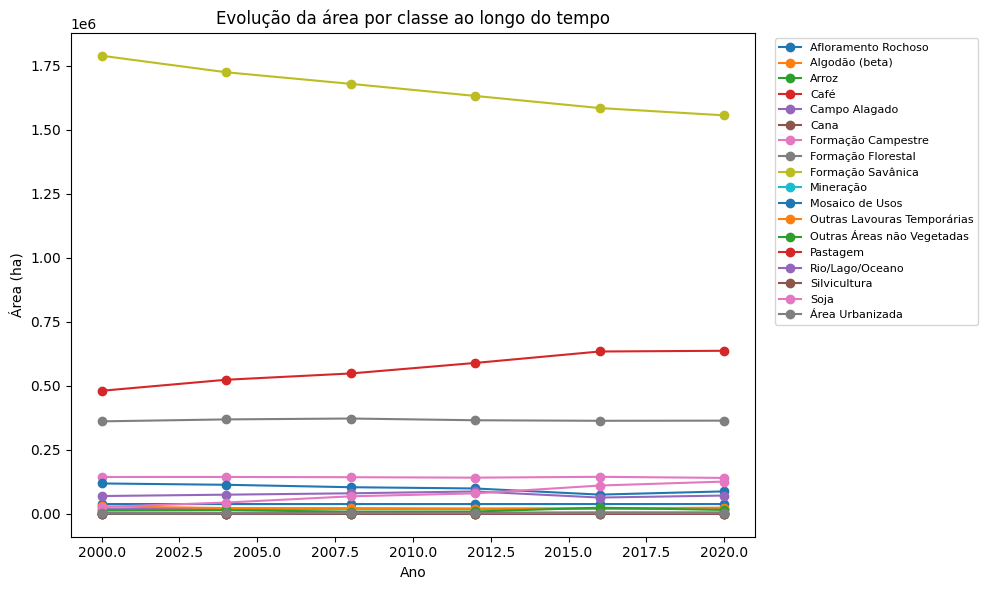

In [ ]:
# Evolução temporal por classe - linha
years = list(range(2000, 2024, 4))
records = []
for y in years:
    img_y = collection9.select(f"classification_{y}").clip(roi)
    df_y = get_area_by_class(img_y, roi)
    df_y["year"] = y
    records.append(df_y)

df_time = pd.concat(records)
pivot_time = df_time.pivot(index="year", columns="class_name", values="area_ha").fillna(0)

plt.figure(figsize=(10, 6))
for col in pivot_time.columns:
    plt.plot(pivot_time.index, pivot_time[col], marker="o", label=col)
plt.ylabel("Área (ha)")
plt.xlabel("Ano")
plt.title("Evolução da área por classe ao longo do tempo")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()



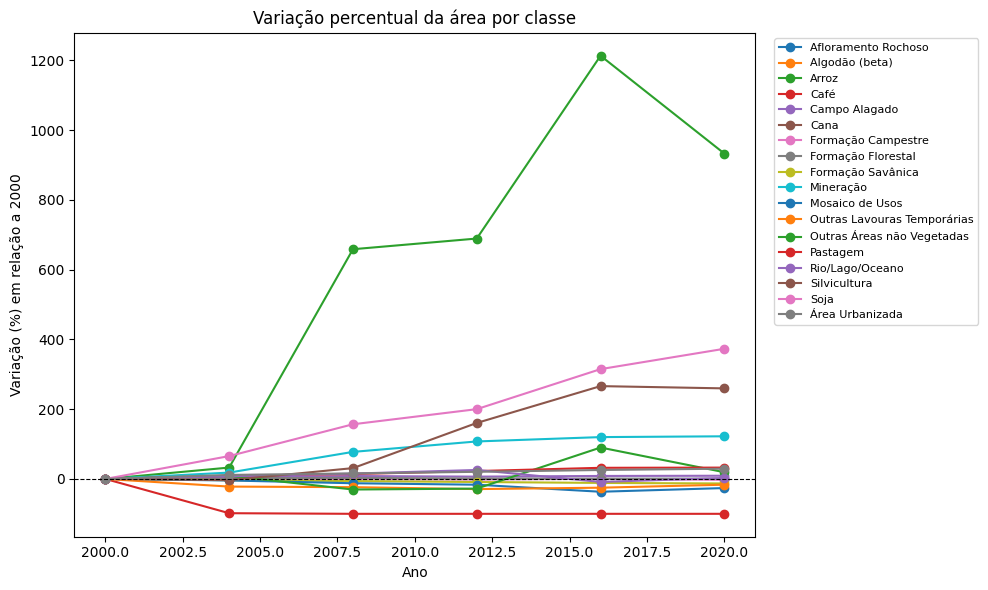

In [ ]:
# Variação percentual relativa ao primeiro ano (revela tendência real)
baseline = pivot_time.iloc[0]
pivot_pct_change = (pivot_time.divide(baseline) - 1) * 100  # % de variação desde o ano base

plt.figure(figsize=(10, 6))
for col in pivot_pct_change.columns:
    plt.plot(pivot_pct_change.index, pivot_pct_change[col], marker="o", label=col)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.ylabel(f"Variação (%) em relação a {pivot_time.index[0]}")
plt.xlabel("Ano")
plt.title("Variação percentual da área por classe")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

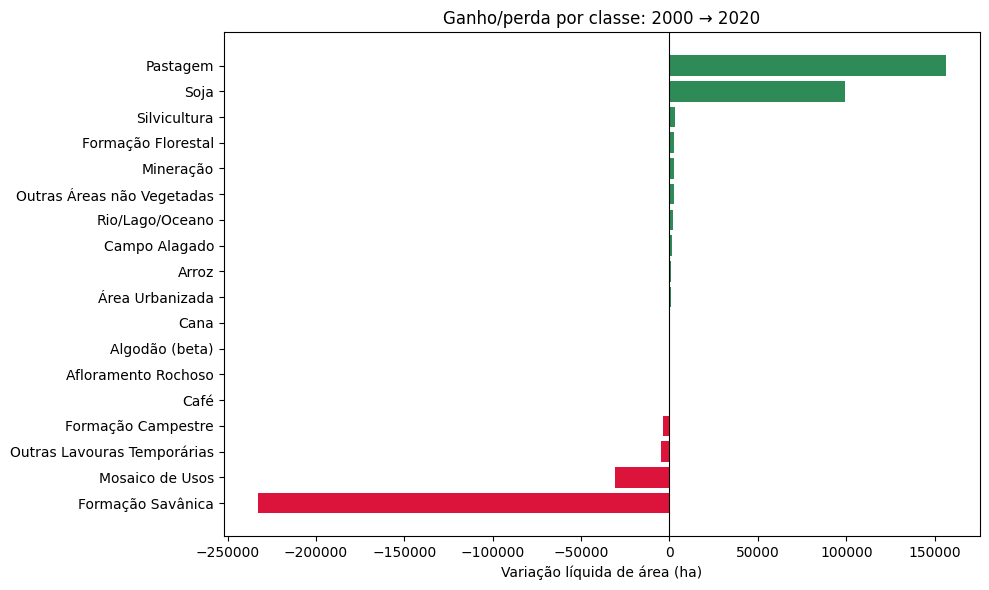

In [ ]:
# Ganho/perda líquida entre primeiro e último ano - barra
net_change = pivot_time.iloc[-1] - pivot_time.iloc[0]
net_change = net_change.sort_values()

plt.figure(figsize=(10, 6))
colors = ["crimson" if v < 0 else "seagreen" for v in net_change]
plt.barh(net_change.index, net_change.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Variação líquida de área (ha)")
plt.title(f"Ganho/perda por classe: {pivot_time.index[0]} → {pivot_time.index[-1]}")
plt.tight_layout()
plt.show()

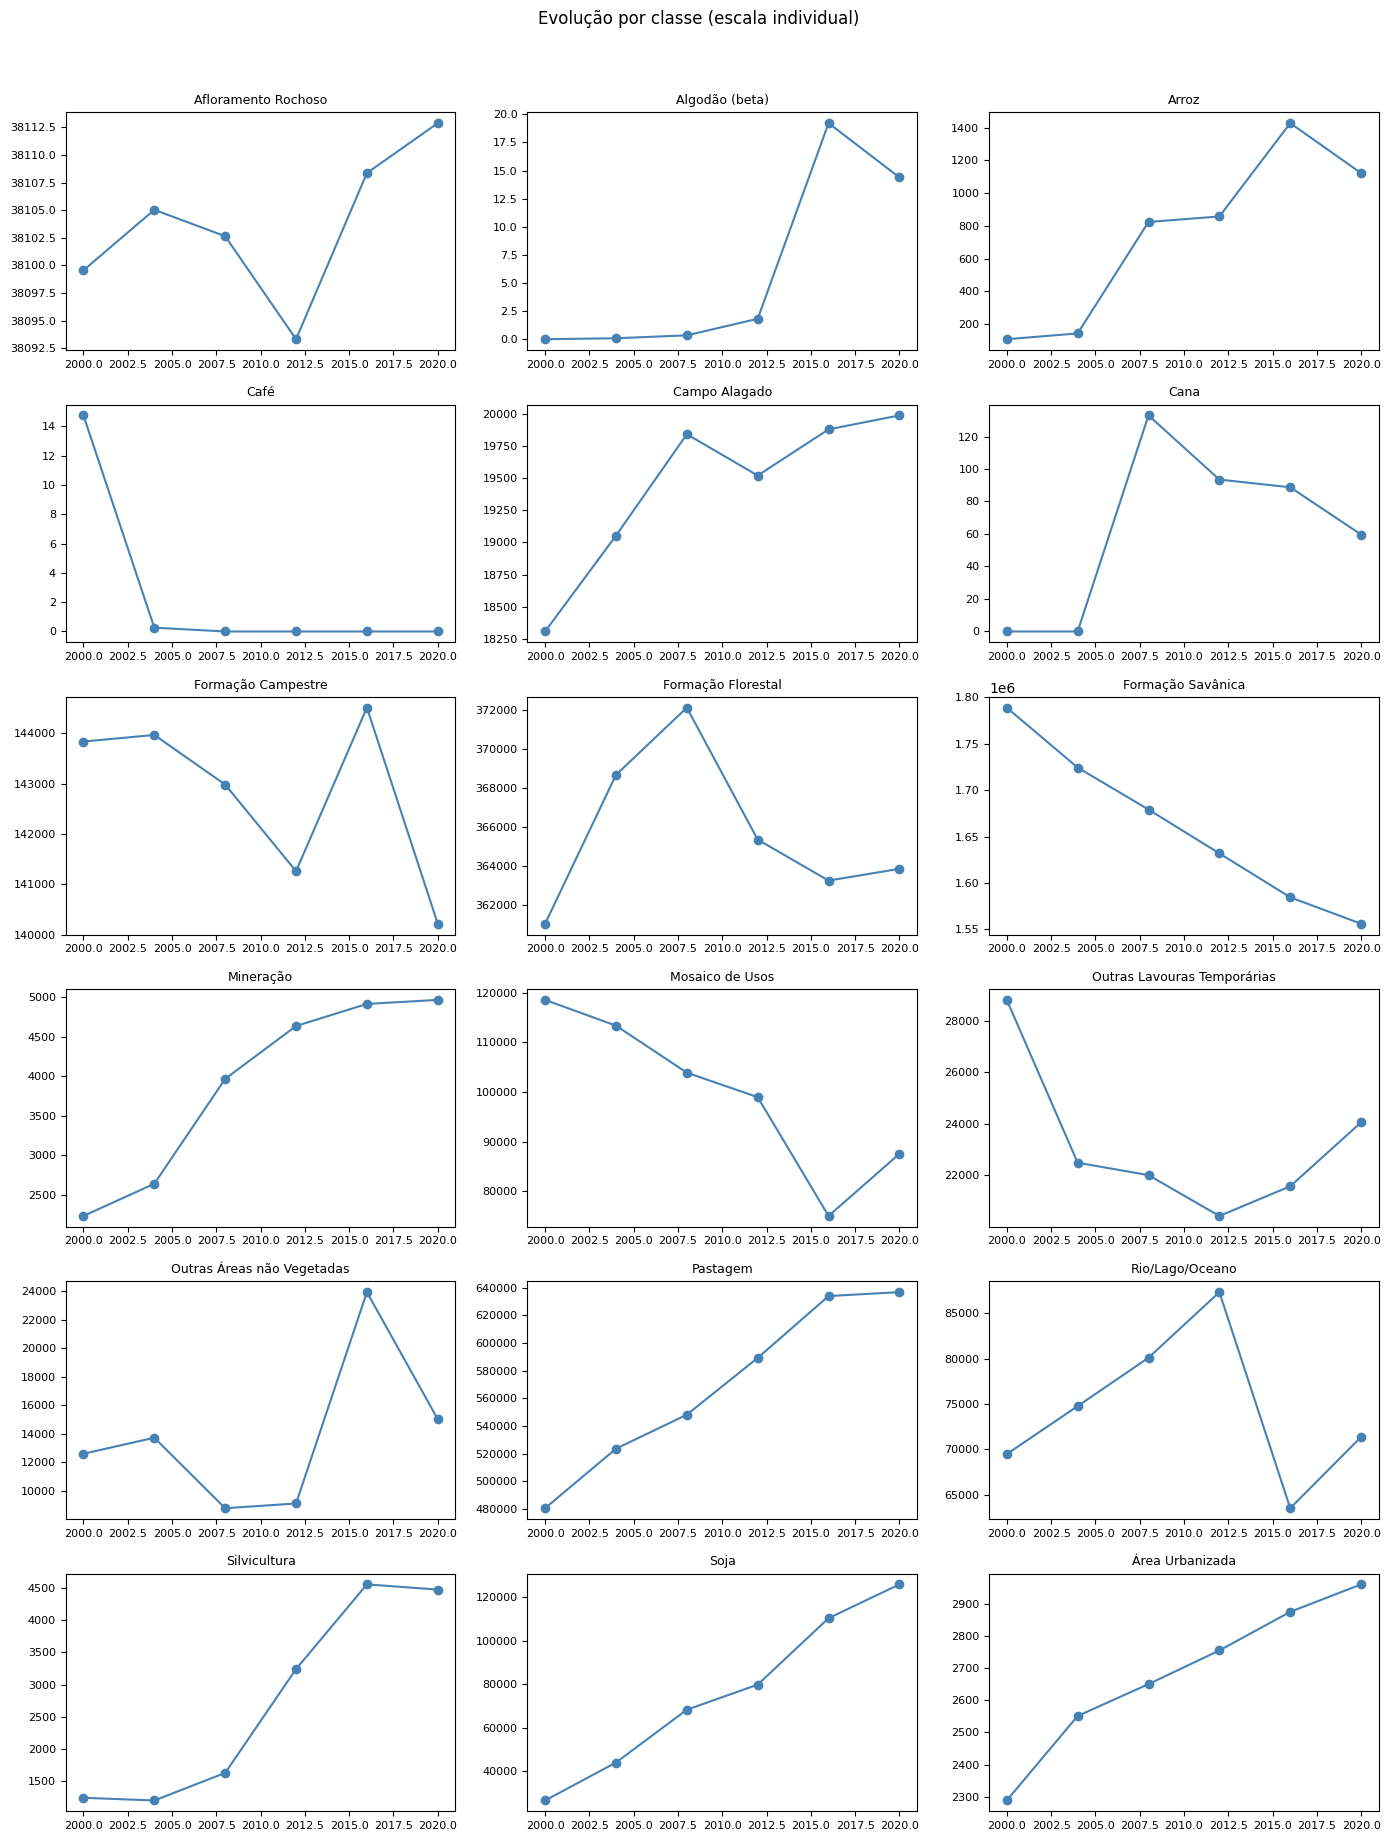

In [ ]:
# Subplots individuais - cada classe com sua própria escala de eixo Y
n_classes = len(pivot_time.columns)
n_cols = 3
n_rows = -(-n_classes // n_cols)  # arredonda pra cima

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(pivot_time.columns):
    axes[i].plot(pivot_time.index, pivot_time[col], marker="o", color="steelblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Evolução por classe (escala individual)", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Elevação e declividade (SRTM) por classe
srtm = ee.Image("USGS/SRTMGL1_003")
slope = ee.Terrain.slope(srtm)

physical_stack = srtm.rename("elevation").addBands(slope.rename("slope")).addBands(classification_map.rename("class"))

physical_stats = physical_stack.reduceRegion(
    reducer=ee.Reducer.mean().group(groupField=2, groupName="class"),
    geometry=roi,
    scale=30,
    maxPixels=1e9,
)

groups_physical = ee.List(physical_stats.get("groups")).getInfo()
print("Elevação/declividade média por classe:")
for g in groups_physical:
    class_id = int(g["class"])
    print(f"  {CLASS_NAMES.get(class_id, class_id)}: {g}")

NameError: name 'ee' is not defined